# Retail Promotions Analysis - Resource 2

This notebook answers the seven client requests using reproducible joins, aggregate metrics, visualizations, and concise business insights.

Metric definitions used throughout:
- Revenue before = base price before promotion x quantity sold before promotion
- Revenue after = base price after promotion x quantity sold after promotion
- ISU% = (total units after - total units before) / total units before x 100
- IR% = (total revenue after - total revenue before) / total revenue before x 100

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
DATA_DIR = Path('datasets')

campaigns = pd.read_csv(DATA_DIR / 'dim_campaigns.csv')
products = pd.read_csv(DATA_DIR / 'dim_products.csv')
stores = pd.read_csv(DATA_DIR / 'dim_stores.csv')
events = pd.read_csv(DATA_DIR / 'fact_events.csv')

print('Shapes:', {'campaigns': campaigns.shape, 'products': products.shape, 'stores': stores.shape, 'events': events.shape})
print('Missing values in events:', int(events.isna().sum().sum()))
print('Exact duplicate event rows:', int(events.duplicated().sum()))

Shapes: {'campaigns': (2, 4), 'products': (15, 3), 'stores': (50, 2), 'events': (1500, 9)}
Missing values in events: 0
Exact duplicate event rows: 0


In [2]:
# Build one analysis table and validate that every fact row matched its dimensions.
df = (events
      .merge(campaigns[['campaign_id', 'campaign_name']], on='campaign_id', how='left', validate='many_to_one')
      .merge(products, on='product_code', how='left', validate='many_to_one')
      .merge(stores, on='store_id', how='left', validate='many_to_one'))

dimension_columns = ['campaign_name', 'product_name', 'category', 'city']
assert not df[dimension_columns].isna().any().any(), 'Some fact rows did not match a dimension table.'

df['revenue_before'] = df['base_price(before_promo)'] * df['quantity_sold(before_promo)']
df['revenue_after'] = df['base_price(after_promo)'] * df['quantity_sold(after_promo)']
df['incremental_units'] = df['quantity_sold(after_promo)'] - df['quantity_sold(before_promo)']
df['incremental_revenue'] = df['revenue_after'] - df['revenue_before']
df.head()

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,product_name,category,city,revenue_before,revenue_after,incremental_units,incremental_revenue
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.00,25% OFF,217,287,Diwali,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,"94,830.00",62279,-40.00,"-32,551.00"
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.00,BOGOF,185,1622,Sankranti,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Chennai,"140,230.00",300070,"1,243.00","159,840.00"
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.00,33% OFF,576,488,Diwali,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Bengaluru,"289,820.00",281088,151.00,"-8,732.00"
3,4f570c,STBLR-7,CAMP_DIW_01,P05,55,122.00,25% OFF,41,107,Diwali,Atliq_Scrub_Sponge_For_Dishwash,Home Care,Bengaluru,"6,710.00",4387,-15.00,"-2,323.00"
4,6d153f,STHYD-5,CAMP_SAN_01,P15,3000,122.00,500 Cashback,2500,272,Sankranti,Atliq_Home_Essential_8_Product_Combo,Combo1,Hyderabad,"366,000.00",680000,150.00,"314,000.00"


## 1. Store distribution by city

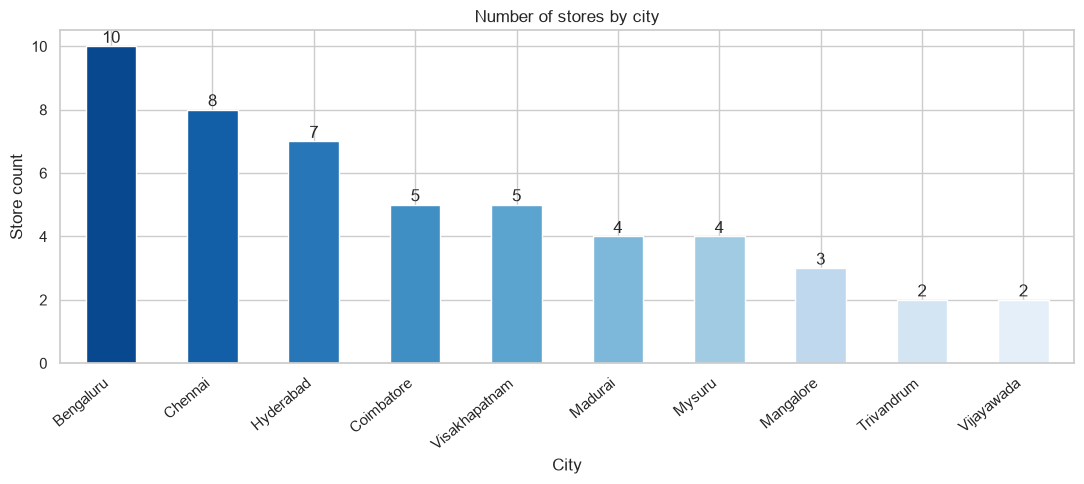

city
Bengaluru        10
Chennai           8
Hyderabad         7
Coimbatore        5
Visakhapatnam     5
Madurai           4
Mysuru            4
Mangalore         3
Trivandrum        2
Vijayawada        2

Most stores: Bengaluru (10 stores)
Bengaluru / Hyderabad / Chennai: {'Bengaluru': 10, 'Hyderabad': 7, 'Chennai': 8}


In [3]:
stores_by_city = stores.groupby('city')['store_id'].nunique().sort_values(ascending=False)
ax = stores_by_city.plot(kind='bar', figsize=(11, 5), color=sns.color_palette('Blues_r', len(stores_by_city)))
ax.set(title='Number of stores by city', xlabel='City', ylabel='Store count')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

comparison = stores_by_city.reindex(['Bengaluru', 'Hyderabad', 'Chennai'])
print(stores_by_city.to_string())
print(f'\nMost stores: {stores_by_city.index[0]} ({stores_by_city.iloc[0]} stores)')
print('Bengaluru / Hyderabad / Chennai:', comparison.to_dict())

## 2. Sankranti post-promotion unit contribution by category

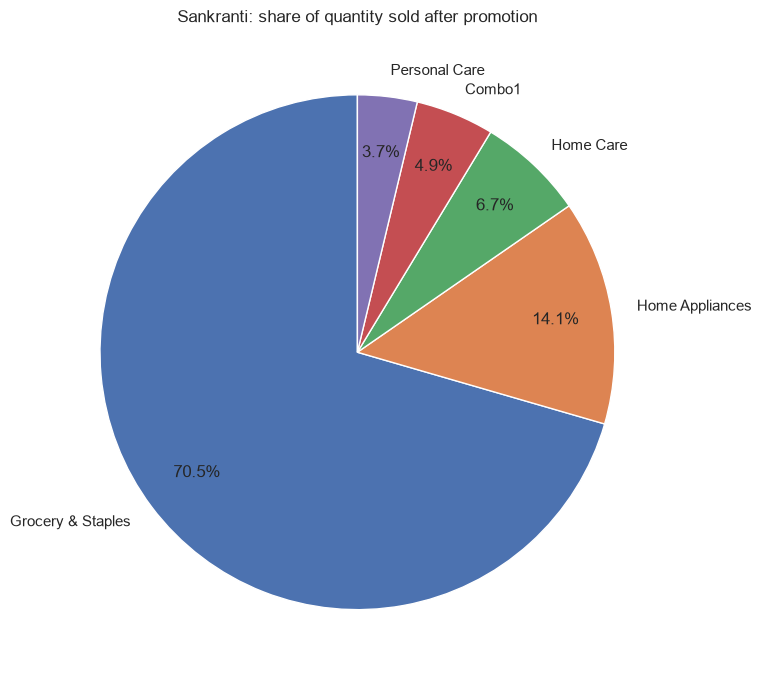

,quantity_after,contribution_pct
category,,
Grocery & Staples,177724,70.51
Home Appliances,35610,14.13
Home Care,16894,6.70
Combo1,12411,4.92
Personal Care,9430,3.74


Top category: Grocery & Staples (70.51% of Sankranti post-promotion units).


In [4]:
sankranti = df.loc[df['campaign_name'].eq('Sankranti')]
sankranti_category = sankranti.groupby('category')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)
sankranti_share = sankranti_category.div(sankranti_category.sum()).mul(100)

fig, ax = plt.subplots(figsize=(8, 7))
ax.pie(sankranti_category, labels=sankranti_category.index, autopct='%1.1f%%', startangle=90, pctdistance=0.78)
ax.set_title('Sankranti: share of quantity sold after promotion')
plt.tight_layout()
plt.show()

result_2 = pd.DataFrame({'quantity_after': sankranti_category, 'contribution_pct': sankranti_share})
display(result_2)
print(f'Top category: {sankranti_share.index[0]} ({sankranti_share.iloc[0]:.2f}% of Sankranti post-promotion units).')

## 3. Correlation between post-promotion price and quantity sold

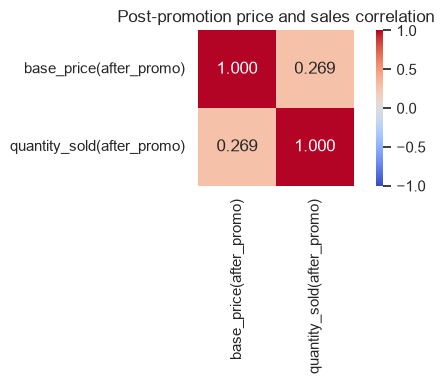

Pearson correlation: 0.269 - a weak positive relationship.
Correlation describes association, not causation; product category and promotion type may confound this relationship.


In [5]:
corr_columns = ['base_price(after_promo)', 'quantity_sold(after_promo)']
corr = df[corr_columns].corr(method='pearson')
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Post-promotion price and sales correlation')
plt.tight_layout()
plt.show()

r = corr.iloc[0, 1]
strength = 'weak' if abs(r) < 0.3 else ('moderate' if abs(r) < 0.7 else 'strong')
direction = 'positive' if r > 0 else 'negative'
print(f'Pearson correlation: {r:.3f} - a {strength} {direction} relationship.')
print('Correlation describes association, not causation; product category and promotion type may confound this relationship.')

## 4. Pre-promotion quantity distribution by product category

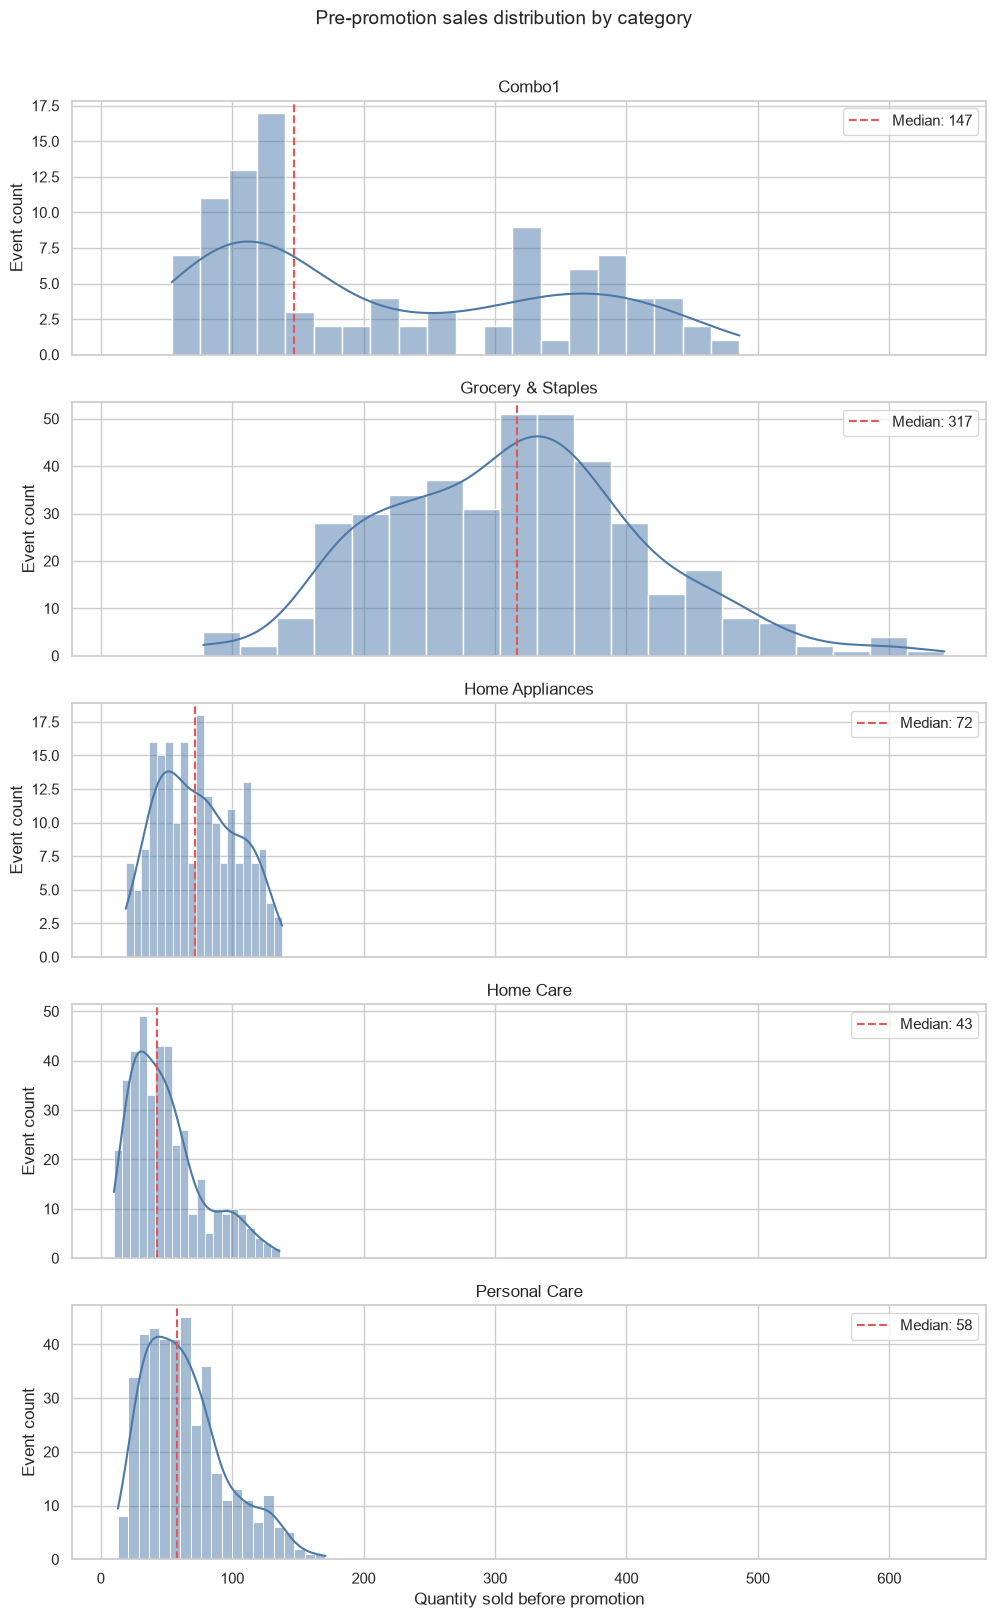

,count,mean,median,std,min,max
category,,,,,,
Grocery & Staples,400,314.79,317.00,99.00,78.00,642.00
Combo1,100,217.30,147.00,129.56,54.00,486.00
Home Appliances,200,73.28,72.00,30.02,19.00,138.00
Personal Care,400,63.78,58.00,31.23,13.00,171.00
Home Care,400,49.59,43.00,27.33,10.00,136.00


In [6]:
categories = sorted(df['category'].unique())
fig, axes = plt.subplots(len(categories), 1, figsize=(10, 3.2 * len(categories)), sharex=True)
if len(categories) == 1:
    axes = [axes]
for ax, category in zip(axes, categories):
    values = df.loc[df['category'].eq(category), 'quantity_sold(before_promo)']
    sns.histplot(values, bins=20, kde=True, ax=ax, color='#4C78A8')
    ax.axvline(values.median(), color='#E45756', linestyle='--', label=f'Median: {values.median():.0f}')
    ax.set_title(category)
    ax.set_ylabel('Event count')
    ax.legend()
axes[-1].set_xlabel('Quantity sold before promotion')
fig.suptitle('Pre-promotion sales distribution by category', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

category_distribution = df.groupby('category')['quantity_sold(before_promo)'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('median', ascending=False)
display(category_distribution)

## 5. Incremental sold units percentage by city

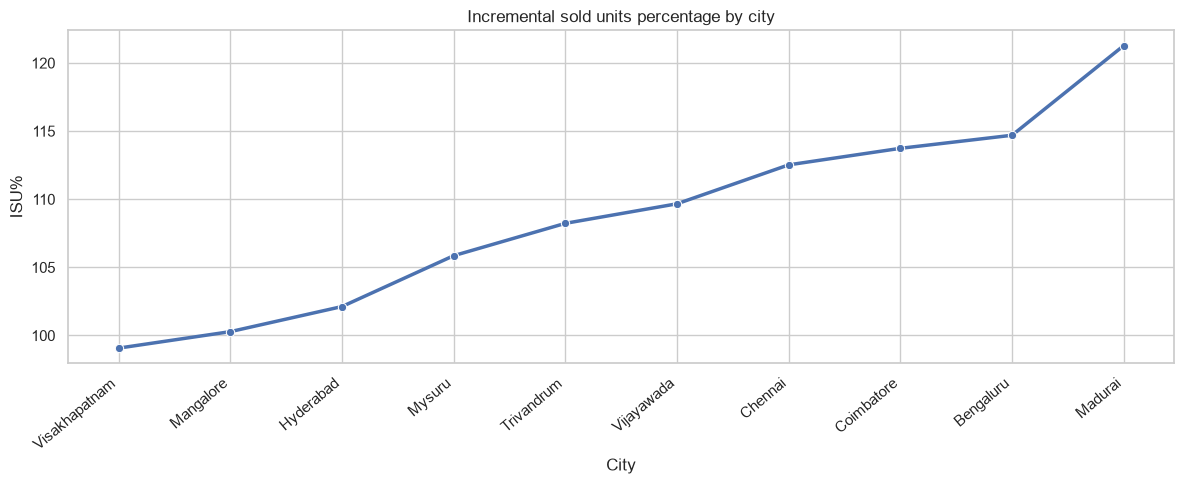

,units_before,units_after,isu_pct
city,,,
Madurai,"14,086.00",31169,121.28
Bengaluru,"48,972.00",105141,114.70
Coimbatore,"18,200.00",38900,113.74
Chennai,"39,183.00",83273,112.52
Vijayawada,"5,297.00",11106,109.67
Trivandrum,"4,884.00",10170,108.23
Mysuru,"18,202.00",37470,105.86
Hyderabad,"34,335.00",69399,102.12
Mangalore,"7,454.00",14929,100.28


Highest ISU%: Madurai (121.28%)
Smallest change: Visakhapatnam (99.07%)


In [7]:
city_units = df.groupby('city').agg(units_before=('quantity_sold(before_promo)', 'sum'), units_after=('quantity_sold(after_promo)', 'sum'))
city_units['isu_pct'] = (city_units['units_after'] - city_units['units_before']) / city_units['units_before'] * 100
city_units = city_units.sort_values('isu_pct', ascending=False)

plot_data = city_units.sort_values('isu_pct')
plt.figure(figsize=(12, 5))
sns.lineplot(x=plot_data.index, y=plot_data['isu_pct'], marker='o', linewidth=2.5)
plt.title('Incremental sold units percentage by city')
plt.xlabel('City')
plt.ylabel('ISU%')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

display(city_units)
print(f'Highest ISU%: {city_units.index[0]} ({city_units.iloc[0]["isu_pct"]:.2f}%)')
print(f'Smallest change: {city_units.index[-1]} ({city_units.iloc[-1]["isu_pct"]:.2f}%)')

## 6. Hyderabad: incremental revenue versus incremental units by promotion type

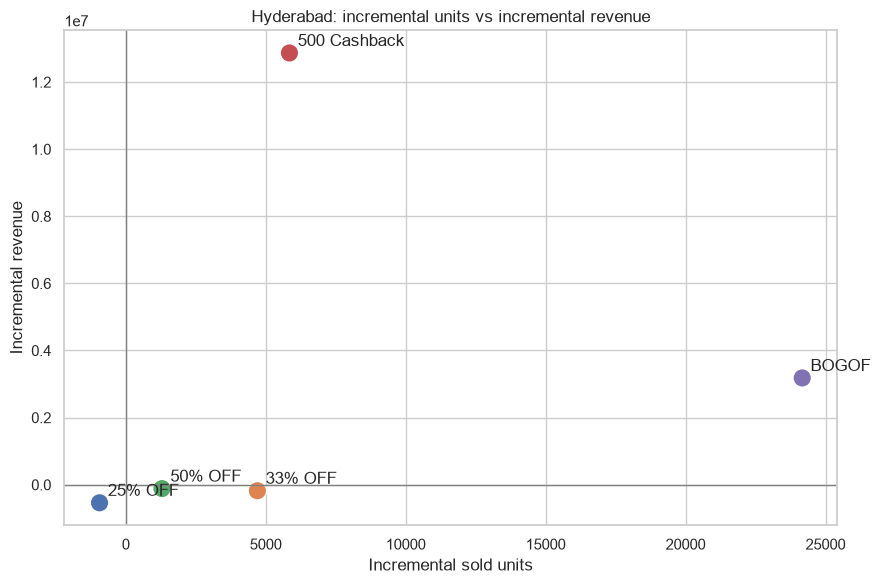

,units_before,units_after,revenue_before,revenue_after,incremental_units,incremental_revenue,isu_pct,ir_pct
promo_type,,,,,,,,
BOGOF,"9,559.00",33727,"4,293,700.00",7476120,"24,168.00","3,182,420.00",252.83,74.12
500 Cashback,"3,492.00",9337,"10,476,000.00",23342500,"5,845.00","12,866,500.00",167.38,122.82
33% OFF,"10,404.00",15104,"6,015,872.00",5836633,"4,700.00","-179,239.00",45.17,-2.98
50% OFF,"3,592.00",4883,"360,534.00",245212,"1,291.00","-115,322.00",35.94,-31.99
25% OFF,"7,288.00",6348,"1,547,135.00",1009192,-940.00,"-537,943.00",-12.90,-34.77


Highest incremental units: BOGOF (24,168)
Highest incremental revenue: 500 Cashback (12,866,500)


In [8]:
hyderabad = df.loc[df['city'].eq('Hyderabad')]
hyd_promo = hyderabad.groupby('promo_type').agg(
    units_before=('quantity_sold(before_promo)', 'sum'),
    units_after=('quantity_sold(after_promo)', 'sum'),
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum'))
hyd_promo['incremental_units'] = hyd_promo['units_after'] - hyd_promo['units_before']
hyd_promo['incremental_revenue'] = hyd_promo['revenue_after'] - hyd_promo['revenue_before']
hyd_promo['isu_pct'] = hyd_promo['incremental_units'] / hyd_promo['units_before'] * 100
hyd_promo['ir_pct'] = hyd_promo['incremental_revenue'] / hyd_promo['revenue_before'] * 100

plt.figure(figsize=(9, 6))
sns.scatterplot(data=hyd_promo, x='incremental_units', y='incremental_revenue', hue='promo_type', s=180)
for promo, row in hyd_promo.iterrows():
    plt.annotate(promo, (row['incremental_units'], row['incremental_revenue']), xytext=(6, 5), textcoords='offset points')
plt.axhline(0, color='grey', linewidth=1)
plt.axvline(0, color='grey', linewidth=1)
plt.title('Hyderabad: incremental units vs incremental revenue')
plt.xlabel('Incremental sold units')
plt.ylabel('Incremental revenue')
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

display(hyd_promo.sort_values('incremental_units', ascending=False))
print(f'Highest incremental units: {hyd_promo["incremental_units"].idxmax()} ({hyd_promo["incremental_units"].max():,.0f})')
print(f'Highest incremental revenue: {hyd_promo["incremental_revenue"].idxmax()} ({hyd_promo["incremental_revenue"].max():,.0f})')

## 7. Bengaluru revenue before and after promotion by category

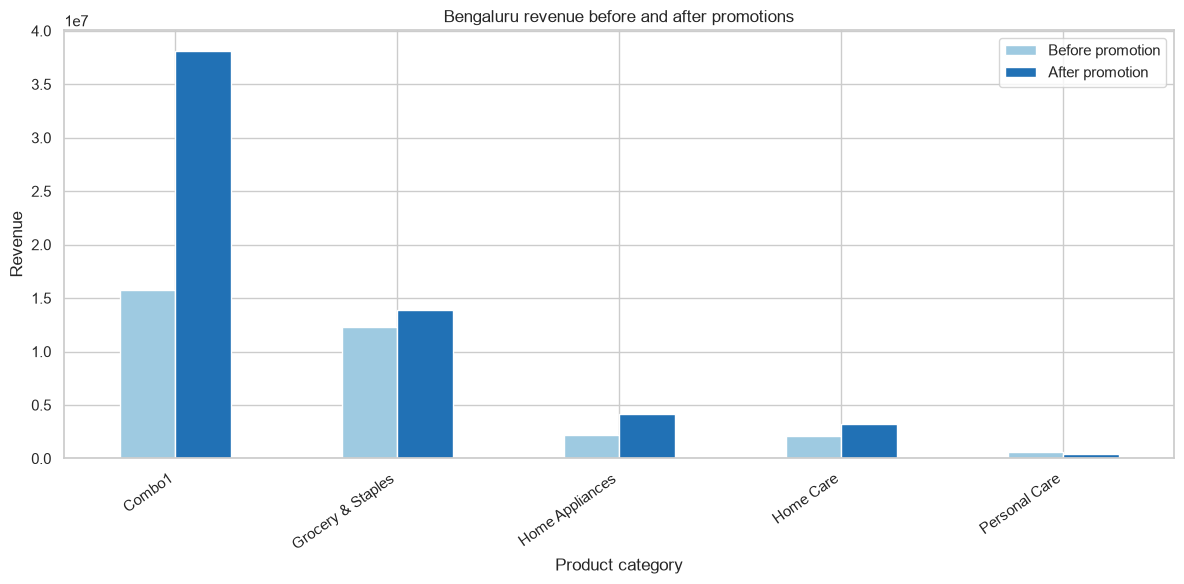

,revenue_before,revenue_after,incremental_revenue,ir_pct
category,,,,
Combo1,"15,777,000.00",38125000,"22,348,000.00",141.65
Grocery & Staples,"12,262,460.00",13861259,"1,598,799.00",13.04
Home Appliances,"2,188,810.00",4122680,"1,933,870.00",88.35
Home Care,"2,104,460.00",3180020,"1,075,560.00",51.11
Personal Care,"576,321.00",389629,"-186,692.00",-32.39


Bengaluru total revenue: 32,909,051 before -> 59,678,588 after (81.34% change).
Largest absolute gain: Combo1 (22,348,000).
Largest percentage gain: Combo1 (141.65%).


In [9]:
bengaluru = df.loc[df['city'].eq('Bengaluru')]
blr_category = bengaluru.groupby('category')[['revenue_before', 'revenue_after']].sum()
blr_category['incremental_revenue'] = blr_category['revenue_after'] - blr_category['revenue_before']
blr_category['ir_pct'] = blr_category['incremental_revenue'] / blr_category['revenue_before'] * 100
blr_category = blr_category.sort_values('revenue_after', ascending=False)

ax = blr_category[['revenue_before', 'revenue_after']].plot(kind='bar', figsize=(12, 6), color=['#9ECAE1', '#2171B5'])
ax.set(title='Bengaluru revenue before and after promotions', xlabel='Product category', ylabel='Revenue')
plt.xticks(rotation=35, ha='right')
plt.legend(['Before promotion', 'After promotion'])
plt.tight_layout()
plt.show()

display(blr_category)
total_before = blr_category['revenue_before'].sum()
total_after = blr_category['revenue_after'].sum()
total_ir = (total_after - total_before) / total_before * 100
print(f'Bengaluru total revenue: {total_before:,.0f} before -> {total_after:,.0f} after ({total_ir:.2f}% change).')
print(f'Largest absolute gain: {blr_category["incremental_revenue"].idxmax()} ({blr_category["incremental_revenue"].max():,.0f}).')
print(f'Largest percentage gain: {blr_category["ir_pct"].idxmax()} ({blr_category["ir_pct"].max():.2f}%).')

## Interpretation notes

- Percentages are calculated from aggregated totals, not by averaging row-level percentages.
- Revenue after promotion uses the supplied post-promotion price, including the effective price already represented for BOGOF rows.
- A strong increase in units does not automatically mean a strong increase in revenue; deep discounts can separate the two outcomes.
- Correlation alone cannot establish that price caused the observed sales quantity.